In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [3]:
#from classy import Class #<< error!
from scipy.interpolate import splrep, splev

In [4]:

class FancyFormatter(Formatter):
    """Formater for values with LaTeX fonts."""

    def __call__(self, v, pos=None):
        return r'${:.5G}$'.format(v)

    def format_data_short(self, value):
        return '{:.1f}'.format(value)

## P(k)

In [5]:
path = './../output/seosBFV/'

seosroot = 'seosv1z'
lcdmroot = 'lcdmz'
#snapshot ={1, 2, 3, 4}
#for s in snapshot
    
    
pkseosz0 = np.loadtxt(path+seosroot+'1'+'_pk.dat')
pklcdmz0 = np.loadtxt(path+lcdmroot+'1'+'_pk.dat')

## interpolation to make ratio

In [45]:
pkseosz0_rep = splrep(pkseosz0[:, 0], pkseosz0[:, 1], k=5)
pklcdmz0_rep = splrep(pklcdmz0[:, 0], pklcdmz0[:, 1], k=5)


krange = logspace(log10(1.07e-5), 1, 1200)

pkseosz0_ev = splev(krange, pkseosz0_rep)
pklcdmz0_ev = splev(krange, pklcdmz0_rep)


In [37]:
#splrep?

## P(k, z=0)

(1.53, 1.59)

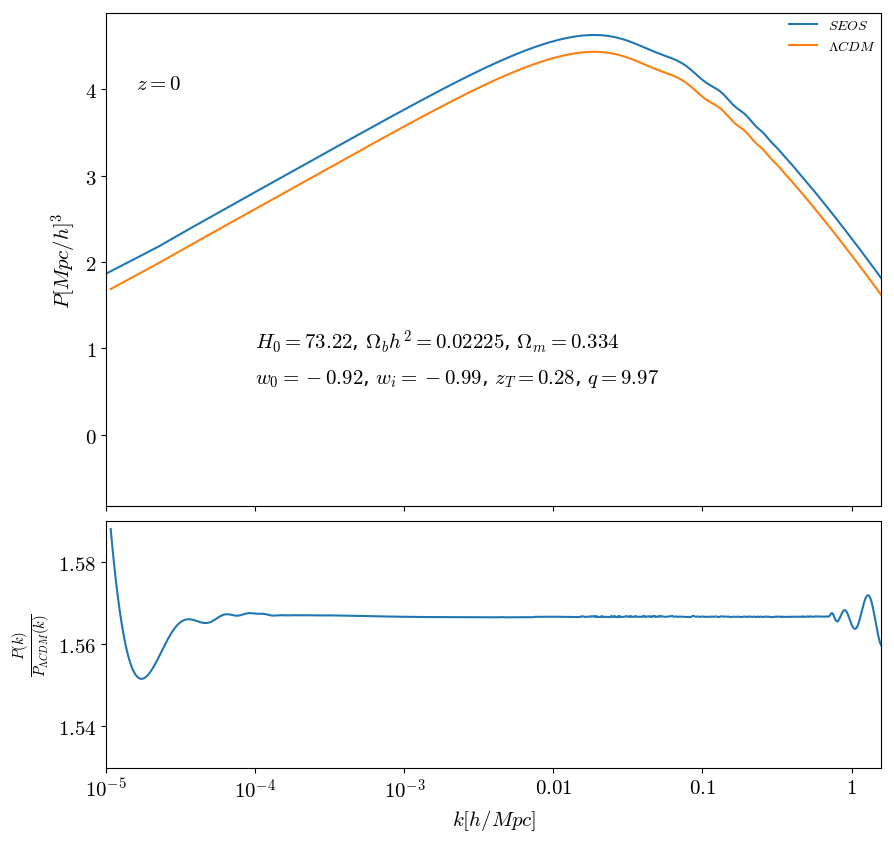

In [78]:
#now we are ready to plot the outputs from CLASS and the ratio, using the interpolation above
figsize = (10, 10)
dpi = 100

rcParams['font.size'] = 15
rcParams['lines.linewidth'] = 1.5
rcParams['mathtext.fontset'] = 'cm'

fig1=figure(figsize=figsize, dpi=dpi)

grid_spec = GridSpec(2, 1, height_ratios=[2, 1])
subplots_adjust(hspace=0.04)

###first subplot ####
subplot(grid_spec[0])
cax = gca()
plot(log10(pkseosz0[:,0]),log10(pkseosz0[:,1]),  label=r'$SEOS$')#'gd', ms=3, alpha = 0.5,
#plot(log10(krange),log10(pkseosz0_ev), label=r'$SEOS$ spline') #spline
plot(log10(pklcdmz0[:,0]),log10(pklcdmz0[:,1]), label=r'$\Lambda CDM$') #'rd', ms=3, alpha = 0.5,
#plot(log10(krange),log10(pklcdmz0_ev), label=r'$\Lambda CDM$ spline') #spline

xlim(-5, 0.2)

ylabel(r'$P [Mpc/h]^3$')
plt.text(-4.8, 4, r'$z=0$')
plt.text(-4, 1, r'$H_0 = 73.22$, $\Omega_bh^2=0.02225$, $\Omega_m = 0.334$')
plt.text(-4, 0.6, r'$w_0 = -0.92$, $w_i = -0.99$, $z_T = 0.28$, $q=9.97$')

legend(loc='best', borderaxespad=0.,prop={'size':10}, frameon=False)
cax.axes.yaxis.set_ticklabels([0,1,10,100,1000,10000])


cax.yaxis.set_major_formatter(FancyFormatter())
cax.xaxis.set_major_formatter(FancyFormatter())

cax.axes.xaxis.set_ticklabels([]) #removing tick labels for x-axis in first plot after fancyformatter


### second subplot ###
subplot(grid_spec[1])
cax2 = gca()

plot(log10(krange), pkseosz0_ev/pklcdmz0_ev)
#plot(log10(krange), pkseosz0_ev/pklcdmz0_ev, 'bo', alpha=0.1)

xlabel(r'$k[h/Mpc]$')
ylabel(r'$\frac{P(k)}{P_{\Lambda CDM}(k)}$')


cax2.yaxis.set_major_formatter(FancyFormatter())
cax2.xaxis.set_major_formatter(FancyFormatter())
cax2.axes.xaxis.set_ticklabels(['$10^{-5}$','$10^{-4}$','$10^{-3}$','$0.01$', '$0.1$', '$1$'])

xlim(-5, 0.2)
ylim(1.53, 1.59)

#savefig('./../figs/pk_z0_ratio_fancy.pdf',bbox_inches='tight')

## P(k, z=$z_T$)

In [79]:
pkseosz028 = np.loadtxt(path+seosroot+'2'+'_pk.dat')
pklcdmz028 = np.loadtxt(path+lcdmroot+'2'+'_pk.dat')

In [81]:
pkseosz028.min(), pkseosz028[:,0].max(), pklcdmz028.min(), pklcdmz028[:,0].max(), pkseosz028.shape

(9.7889669220829998e-06,
 11.42881310576,
 1.0720262146530001e-05,
 11.789464086220001,
 (604, 2))

In [82]:
pkseosz028_rep = splrep(pkseosz028[:, 0], pkseosz028[:, 1], k=5)
pklcdmz028_rep = splrep(pklcdmz028[:, 0], pklcdmz028[:, 1], k=5)


krange = logspace(log10(1.07e-5), 1, 1200)

pkseosz028_ev = splev(krange, pkseosz028_rep)
pklcdmz028_ev = splev(krange, pklcdmz028_rep)

(1.26, 1.33)

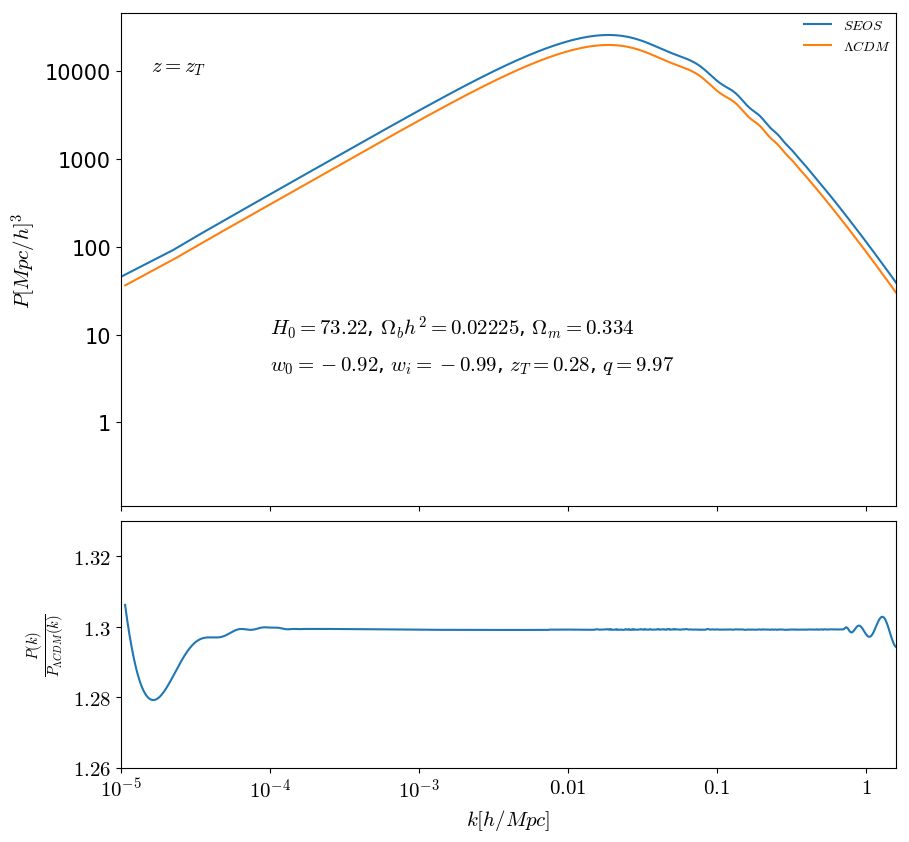

In [110]:
#now we are ready to plot the outputs from CLASS and the ratio, using the interpolation above
figsize = (10, 10)
dpi = 100

rcParams['font.size'] = 15
rcParams['lines.linewidth'] = 1.5
rcParams['mathtext.fontset'] = 'cm'

fig1=figure(figsize=figsize, dpi=dpi)

grid_spec = GridSpec(2, 1, height_ratios=[2, 1])
subplots_adjust(hspace=0.04)

###first subplot ####
subplot(grid_spec[0])
cax = gca()
plot(log10(pkseosz028[:,0]),log10(pkseosz028[:,1]),  label=r'$SEOS$')
#plot(log10(krange),log10(pkseosz0_ev), label=r'$SEOS$ spline') #spline
plot(log10(pklcdmz028[:,0]),log10(pklcdmz028[:,1]), label=r'$\Lambda CDM$') #'rd', ms=3, alpha = 0.5,
#plot(log10(krange),log10(pklcdmz0_ev), label=r'$\Lambda CDM$ spline') #spline

xlim(-5, 0.2)

ylabel(r'$P [Mpc/h]^3$')
plt.text(-4.8, 4, r'$z=z_T$')
plt.text(-4, 1, r'$H_0 = 73.22$, $\Omega_bh^2=0.02225$, $\Omega_m = 0.334$')
plt.text(-4, 0.6, r'$w_0 = -0.92$, $w_i = -0.99$, $z_T = 0.28$, $q=9.97$')

legend(loc='best', borderaxespad=0.,prop={'size':10}, frameon=False)

cax.yaxis.set_major_formatter(FancyFormatter())
cax.xaxis.set_major_formatter(FancyFormatter())

cax.axes.yaxis.set_ticklabels([0,1,10,100,1000,10000])
cax.axes.xaxis.set_ticklabels([]) #removing tick labels for x-axis in first plot after fancyformatter


### second subplot ###
subplot(grid_spec[1])
cax2 = gca()

plot(log10(krange), pkseosz028_ev/pklcdmz028_ev)
#plot(log10(krange), pkseosz0_ev/pklcdmz0_ev, 'bo', alpha=0.1)

xlabel(r'$k[h/Mpc]$')
ylabel(r'$\frac{P(k)}{P_{\Lambda CDM}(k)}$')


cax2.yaxis.set_major_formatter(FancyFormatter())
cax2.xaxis.set_major_formatter(FancyFormatter())
cax2.axes.xaxis.set_ticklabels(['$10^{-5}$','$10^{-4}$','$10^{-3}$','$0.01$', '$0.1$', '$1$'])

xlim(-5, 0.2)
ylim(1.26, 1.33)

#savefig('./../figs/pk_zT_ratio_fancy.pdf',bbox_inches='tight')

## P(k, z=0.57)

In [94]:
pkseosz057 = np.loadtxt(path+seosroot+'3'+'_pk.dat')
pklcdmz057 = np.loadtxt(path+lcdmroot+'3'+'_pk.dat')

In [96]:
pkseosz057.min(), pklcdmz057.min(), pkseosz057[:,0].max(),pklcdmz057[:,0].max()

(9.7889669220829998e-06,
 1.0720262146530001e-05,
 11.42881310576,
 11.789464086220001)

In [97]:
pkseosz057_rep = splrep(pkseosz057[:, 0], pkseosz057[:, 1], k=5)
pklcdmz057_rep = splrep(pklcdmz057[:, 0], pklcdmz057[:, 1], k=5)


krange = logspace(log10(1.07e-5), 1, 1200)

pkseosz057_ev = splev(krange, pkseosz057_rep)
pklcdmz057_ev = splev(krange, pklcdmz057_rep)

(1.12, 1.2)

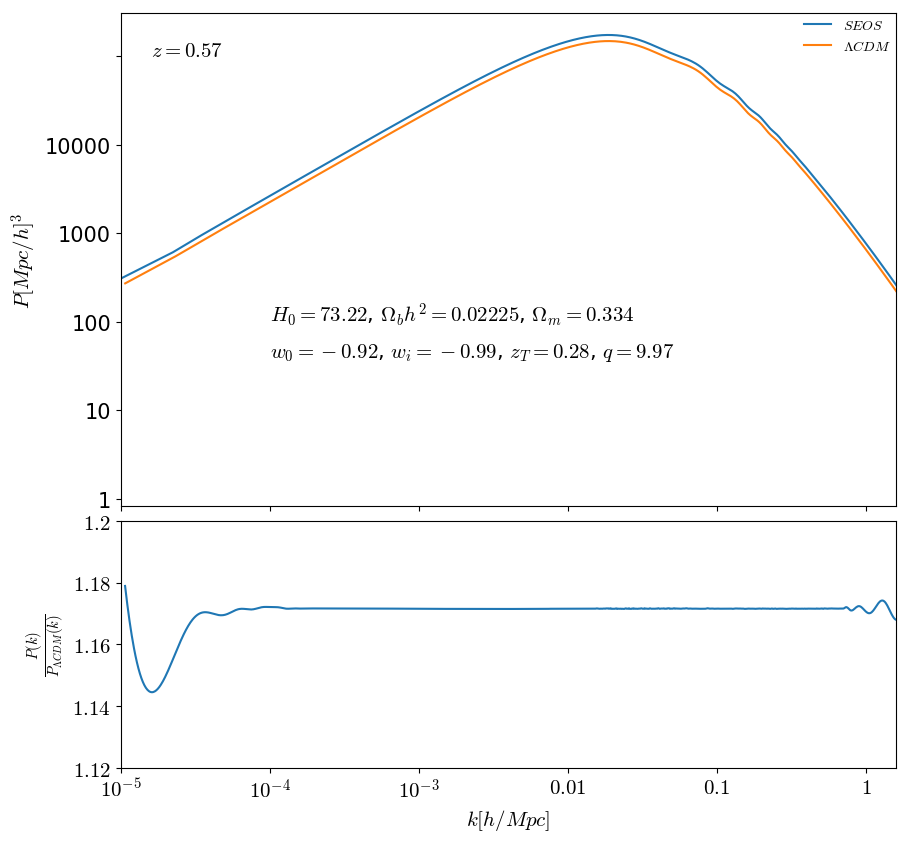

In [111]:
#now we are ready to plot the outputs from CLASS and the ratio, using the interpolation above
figsize = (10, 10)
dpi = 100

rcParams['font.size'] = 15
rcParams['lines.linewidth'] = 1.5
rcParams['mathtext.fontset'] = 'cm'

fig1=figure(figsize=figsize, dpi=dpi)

grid_spec = GridSpec(2, 1, height_ratios=[2, 1])
subplots_adjust(hspace=0.04)

###first subplot ####
subplot(grid_spec[0])
cax = gca()
plot(log10(pkseosz057[:,0]),log10(pkseosz057[:,1]),  label=r'$SEOS$')
#plot(log10(krange),log10(pkseosz0_ev), label=r'$SEOS$ spline') #spline
plot(log10(pklcdmz057[:,0]),log10(pklcdmz057[:,1]), label=r'$\Lambda CDM$') #'rd', ms=3, alpha = 0.5,
#plot(log10(krange),log10(pklcdmz0_ev), label=r'$\Lambda CDM$ spline') #spline

xlim(-5, 0.2)

ylabel(r'$P [Mpc/h]^3$')
plt.text(-4.8, 4, r'$z=0.57$')
plt.text(-4, 1, r'$H_0 = 73.22$, $\Omega_bh^2=0.02225$, $\Omega_m = 0.334$')
plt.text(-4, 0.6, r'$w_0 = -0.92$, $w_i = -0.99$, $z_T = 0.28$, $q=9.97$')

legend(loc='best', borderaxespad=0.,prop={'size':10}, frameon=False)

cax.yaxis.set_major_formatter(FancyFormatter())
cax.xaxis.set_major_formatter(FancyFormatter())

cax.axes.yaxis.set_ticklabels([0,1,10,100,1000,10000])
cax.axes.xaxis.set_ticklabels([]) #removing tick labels for x-axis in first plot after fancyformatter


### second subplot ###
subplot(grid_spec[1])
cax2 = gca()

plot(log10(krange), pkseosz057_ev/pklcdmz057_ev)
#plot(log10(krange), pkseosz0_ev/pklcdmz0_ev, 'bo', alpha=0.1)

xlabel(r'$k[h/Mpc]$')
ylabel(r'$\frac{P(k)}{P_{\Lambda CDM}(k)}$')


cax2.yaxis.set_major_formatter(FancyFormatter())
cax2.xaxis.set_major_formatter(FancyFormatter())
cax2.axes.xaxis.set_ticklabels(['$10^{-5}$','$10^{-4}$','$10^{-3}$','$0.01$', '$0.1$', '$1$'])

xlim(-5, 0.2)
ylim(1.12, 1.2)

#savefig('./../figs/pk_z057_ratio_fancy.pdf',bbox_inches='tight')

## P(k, z=1)

In [107]:
pkseosz1 = np.loadtxt(path+seosroot+'4'+'_pk.dat')
pklcdmz1 = np.loadtxt(path+lcdmroot+'4'+'_pk.dat')

In [108]:
pkseosz1_rep = splrep(pkseosz1[:, 0], pkseosz1[:, 1], k=5)
pklcdmz1_rep = splrep(pklcdmz1[:, 0], pklcdmz1[:, 1], k=5)


krange = logspace(log10(1.07e-5), 1, 1200)

pkseosz1_ev = splev(krange, pkseosz1_rep)
pklcdmz1_ev = splev(krange, pklcdmz1_rep)

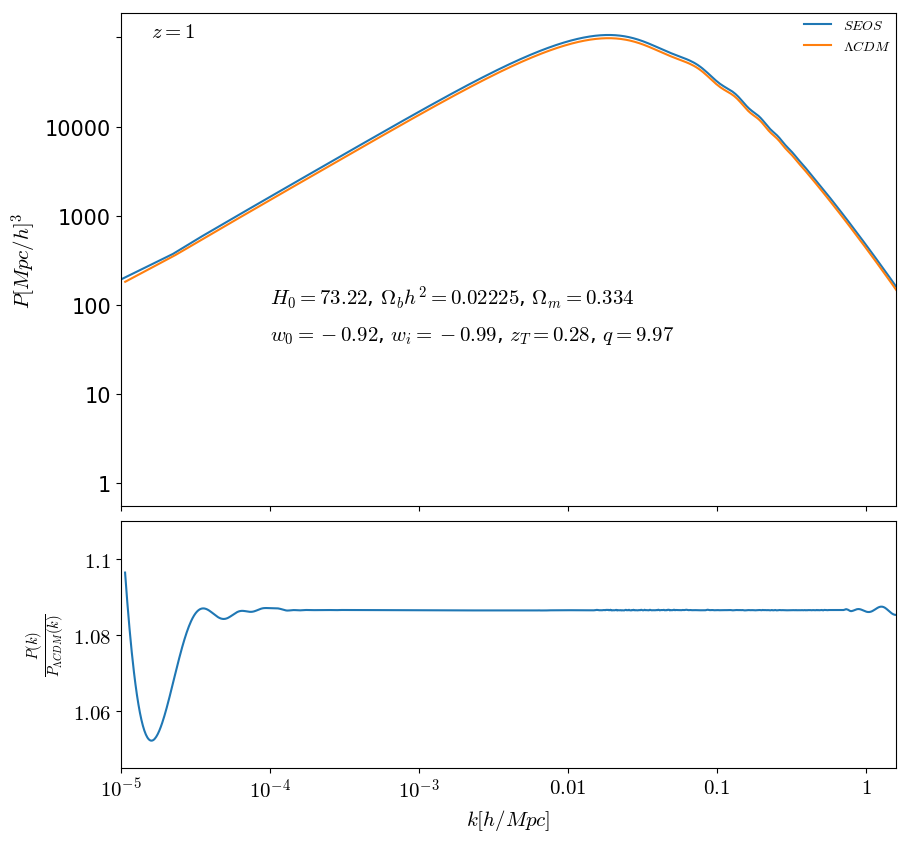

In [116]:
#now we are ready to plot the outputs from CLASS and the ratio, using the interpolation above
figsize = (10, 10)
dpi = 100

rcParams['font.size'] = 15
rcParams['lines.linewidth'] = 1.5
rcParams['mathtext.fontset'] = 'cm'

fig1=figure(figsize=figsize, dpi=dpi)

grid_spec = GridSpec(2, 1, height_ratios=[2, 1])
subplots_adjust(hspace=0.04)

###first subplot ####
subplot(grid_spec[0])
cax = gca()
plot(log10(pkseosz1[:,0]),log10(pkseosz1[:,1]),  label=r'$SEOS$')
#plot(log10(krange),log10(pkseosz0_ev), label=r'$SEOS$ spline') #spline
plot(log10(pklcdmz1[:,0]),log10(pklcdmz1[:,1]), label=r'$\Lambda CDM$') #'rd', ms=3, alpha = 0.5,
#plot(log10(krange),log10(pklcdmz0_ev), label=r'$\Lambda CDM$ spline') #spline

xlim(-5, 0.2)
ylim()
ylabel(r'$P [Mpc/h]^3$')
plt.text(-4.8, 4, r'$z=1$')
plt.text(-4, 1, r'$H_0 = 73.22$, $\Omega_bh^2=0.02225$, $\Omega_m = 0.334$')
plt.text(-4, 0.6, r'$w_0 = -0.92$, $w_i = -0.99$, $z_T = 0.28$, $q=9.97$')

legend(loc='best', borderaxespad=0.,prop={'size':10}, frameon=False)

cax.yaxis.set_major_formatter(FancyFormatter())
cax.xaxis.set_major_formatter(FancyFormatter())

cax.axes.yaxis.set_ticklabels([0,1,10,100,1000,10000])
cax.axes.xaxis.set_ticklabels([]) #removing tick labels for x-axis in first plot after fancyformatter


### second subplot ###
subplot(grid_spec[1])
cax2 = gca()

plot(log10(krange), pkseosz1_ev/pklcdmz1_ev)
#plot(log10(krange), pkseosz0_ev/pklcdmz0_ev, 'bo', alpha=0.1)

xlabel(r'$k[h/Mpc]$')
ylabel(r'$\frac{P(k)}{P_{\Lambda CDM}(k)}$')


cax2.yaxis.set_major_formatter(FancyFormatter())
cax2.xaxis.set_major_formatter(FancyFormatter())
cax2.axes.xaxis.set_ticklabels(['$10^{-5}$','$10^{-4}$','$10^{-3}$','$0.01$', '$0.1$', '$1$'])

xlim(-5, 0.2)
ylim(1.045, 1.11)

#savefig('./../figs/pk_z1_ratio_fancy.pdf',bbox_inches='tight')

## P(k, z=2.3)

In [117]:
pkseosz2_3 = np.loadtxt(path+seosroot+'5'+'_pk.dat')
pklcdmz2_3 = np.loadtxt(path+lcdmroot+'5'+'_pk.dat')

In [123]:
pkseosz2_3.min(), pklcdmz2_3.min(), pklcdmz2_3[:,0].max(), pkseosz2_3[:,0].max()

(9.7889669220829998e-06,
 1.0720262146530001e-05,
 11.789464086220001,
 11.42881310576)

In [118]:
pkseosz2_3_rep = splrep(pkseosz2_3[:, 0], pkseosz2_3[:, 1], k=5)
pklcdmz2_3_rep = splrep(pklcdmz2_3[:, 0], pklcdmz2_3[:, 1], k=5)


krange = logspace(log10(1.07e-5), 1, 1200)

pkseosz2_3_ev = splev(krange, pkseosz2_3_rep)
pklcdmz2_3_ev = splev(krange, pklcdmz2_3_rep)

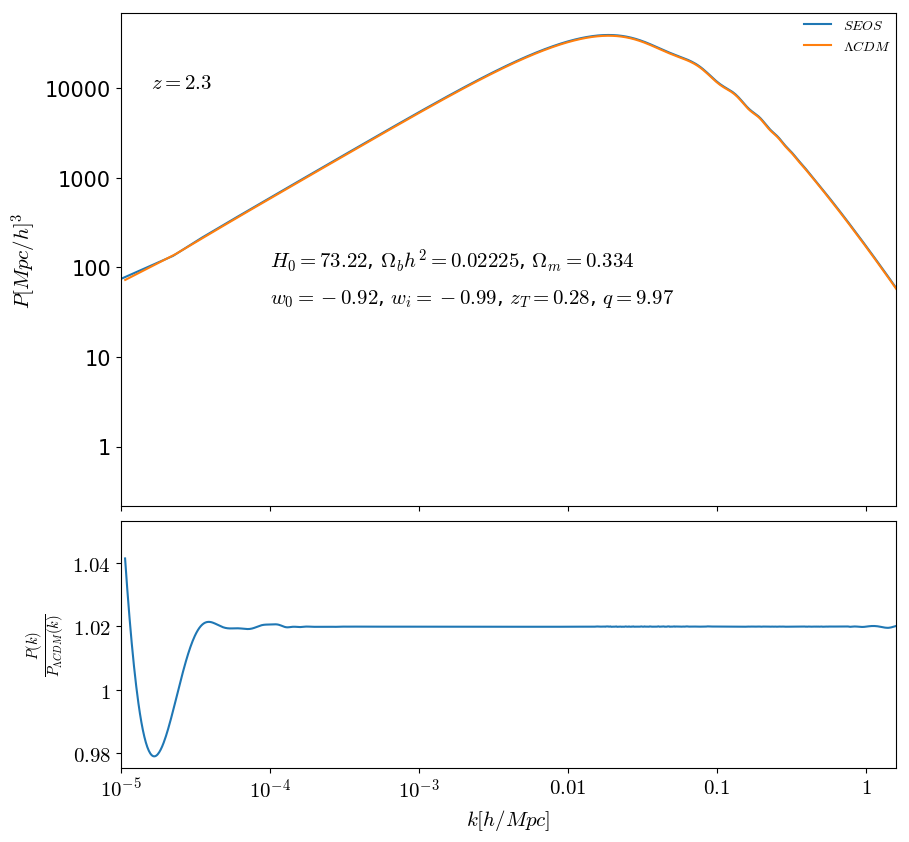

In [121]:
#now we are ready to plot the outputs from CLASS and the ratio, using the interpolation above
figsize = (10, 10)
dpi = 100

rcParams['font.size'] = 15
rcParams['lines.linewidth'] = 1.5
rcParams['mathtext.fontset'] = 'cm'

fig1=figure(figsize=figsize, dpi=dpi)

grid_spec = GridSpec(2, 1, height_ratios=[2, 1])
subplots_adjust(hspace=0.04)

###first subplot ####
subplot(grid_spec[0])
cax = gca()
plot(log10(pkseosz2_3[:,0]),log10(pkseosz2_3[:,1]),  label=r'$SEOS$')
#plot(log10(krange),log10(pkseosz0_ev), label=r'$SEOS$ spline') #spline
plot(log10(pklcdmz2_3[:,0]),log10(pklcdmz2_3[:,1]), label=r'$\Lambda CDM$') #'rd', ms=3, alpha = 0.5,
#plot(log10(krange),log10(pklcdmz0_ev), label=r'$\Lambda CDM$ spline') #spline

xlim(-5, 0.2)
ylim()
ylabel(r'$P [Mpc/h]^3$')
plt.text(-4.8, 3, r'$z=2.3$')
plt.text(-4, 1, r'$H_0 = 73.22$, $\Omega_bh^2=0.02225$, $\Omega_m = 0.334$')
plt.text(-4, 0.6, r'$w_0 = -0.92$, $w_i = -0.99$, $z_T = 0.28$, $q=9.97$')

legend(loc='best', borderaxespad=0.,prop={'size':10}, frameon=False)

cax.yaxis.set_major_formatter(FancyFormatter())
cax.xaxis.set_major_formatter(FancyFormatter())

cax.axes.yaxis.set_ticklabels([0,1,10,100,1000,10000])
cax.axes.xaxis.set_ticklabels([]) #removing tick labels for x-axis in first plot after fancyformatter


### second subplot ###
subplot(grid_spec[1])
cax2 = gca()

plot(log10(krange), pkseosz2_3_ev/pklcdmz2_3_ev)
#plot(log10(krange), pkseosz0_ev/pklcdmz0_ev, 'bo', alpha=0.1)

xlabel(r'$k[h/Mpc]$')
ylabel(r'$\frac{P(k)}{P_{\Lambda CDM}(k)}$')


cax2.yaxis.set_major_formatter(FancyFormatter())
cax2.xaxis.set_major_formatter(FancyFormatter())
cax2.axes.xaxis.set_ticklabels(['$10^{-5}$','$10^{-4}$','$10^{-3}$','$0.01$', '$0.1$', '$1$'])

xlim(-5, 0.2)
#ylim(1.045, 1.11)

#savefig('./../figs/pk_z2_3_ratio_fancy.pdf',bbox_inches='tight')

In [133]:
def interp_spline(pkdata):
    pk_rep = splrep(pkdata[:,0], pkdata[:,1], k=5)
    krange = logspace(log10(1.07e-5), 1, 1200)
    pk_ev = splev(krange, pk_rep)
    return pk_ev
    
def plot_pk(pk1, pk2, s):
    '''
    Plot 2 different power spectra already interpolated using spline with k=5
    Plot the ratio among them in the bottom panel
    
    '''
    #now we are ready to plot the outputs from CLASS and the ratio, using the interpolation above
    figsize = (10, 10)
    dpi = 100

    rcParams['font.size'] = 15
    rcParams['lines.linewidth'] = 1.5
    rcParams['mathtext.fontset'] = 'cm'

    fig1=figure(figsize=figsize, dpi=dpi)

    grid_spec = GridSpec(2, 1, height_ratios=[2, 1])
    subplots_adjust(hspace=0.04)

    ###first subplot ####
    subplot(grid_spec[0])
    cax = gca()
    plot(log10(krange),log10(pk1),  label=r'$SEOS$')
    plot(log10(krange),log10(pk2),  label=r'$\Lambda CDM$') 

    xlim(-5, 0.2)
    ylim()
    ylabel(r'$P [Mpc/h]^3$')
    #plt.text(-4.8, 3, r'$z=2.3$')
    plt.text(-4, 1, r'$H_0 = 73.22$, $\Omega_bh^2=0.02225$, $\Omega_m = 0.334$')
    plt.text(-4, 0.6, r'$w_0 = -0.92$, $w_i = -0.99$, $z_T = 0.28$, $q=9.97$')

    legend(loc='best', borderaxespad=0.,prop={'size':10}, frameon=False)

    cax.yaxis.set_major_formatter(FancyFormatter())
    cax.xaxis.set_major_formatter(FancyFormatter())

    cax.axes.yaxis.set_ticklabels([0,1,10,100,1000,10000])
    cax.axes.xaxis.set_ticklabels([]) #removing tick labels for x-axis in first plot after fancyformatter

    ### second subplot ###
    subplot(grid_spec[1])
    cax2 = gca()

    plot(log10(krange), pk1/pk2)
    #plot(log10(krange), pkseosz0_ev/pklcdmz0_ev, 'bo', alpha=0.1)

    xlabel(r'$k[h/Mpc]$')
    ylabel(r'$\frac{P(k)}{P_{\Lambda CDM}(k)}$')


    cax2.yaxis.set_major_formatter(FancyFormatter())
    cax2.xaxis.set_major_formatter(FancyFormatter())
    cax2.axes.xaxis.set_ticklabels(['$10^{-5}$','$10^{-4}$','$10^{-3}$','$0.01$', '$0.1$', '$1$'])

    xlim(-5, 0.2)
    #ylim(1.045, 1.11)
    
    figname = 'pk_z_'+str(s)+'_ratio.pdf'
    #savefig('./../figs/'+figname, bbox_inches='tight')

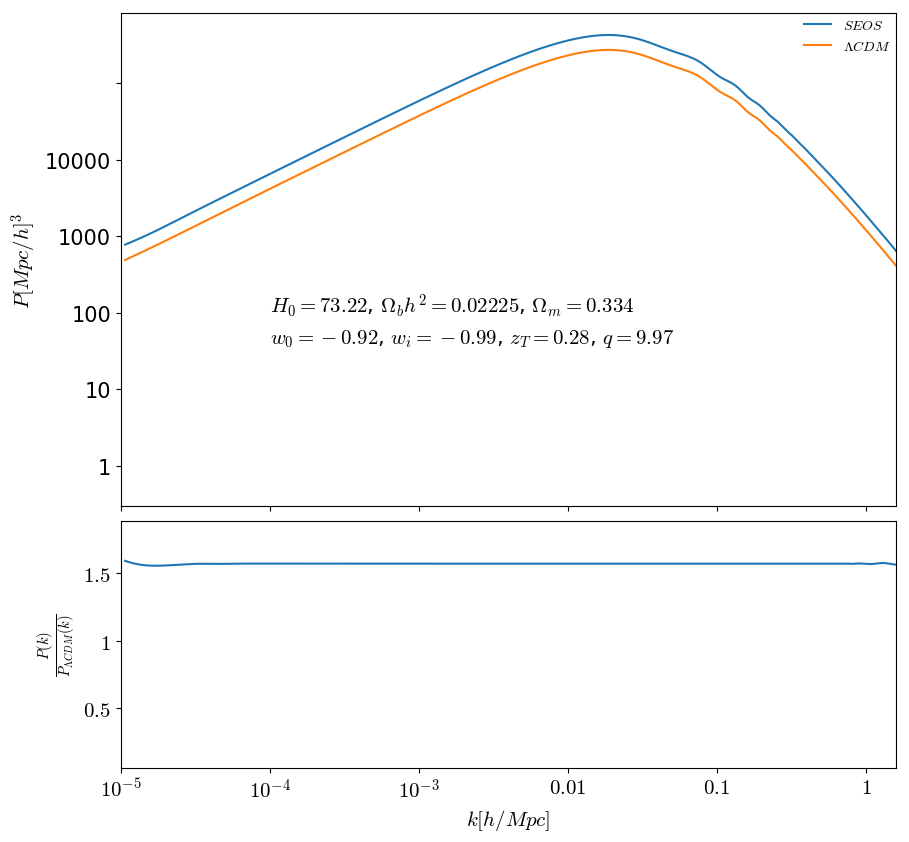

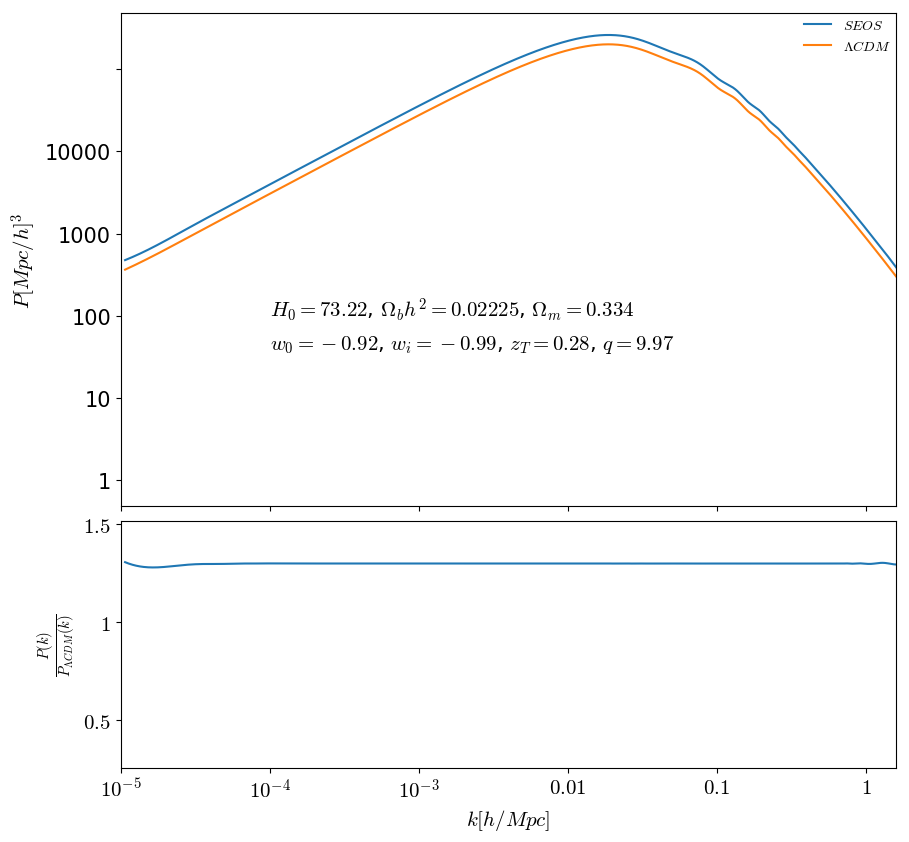

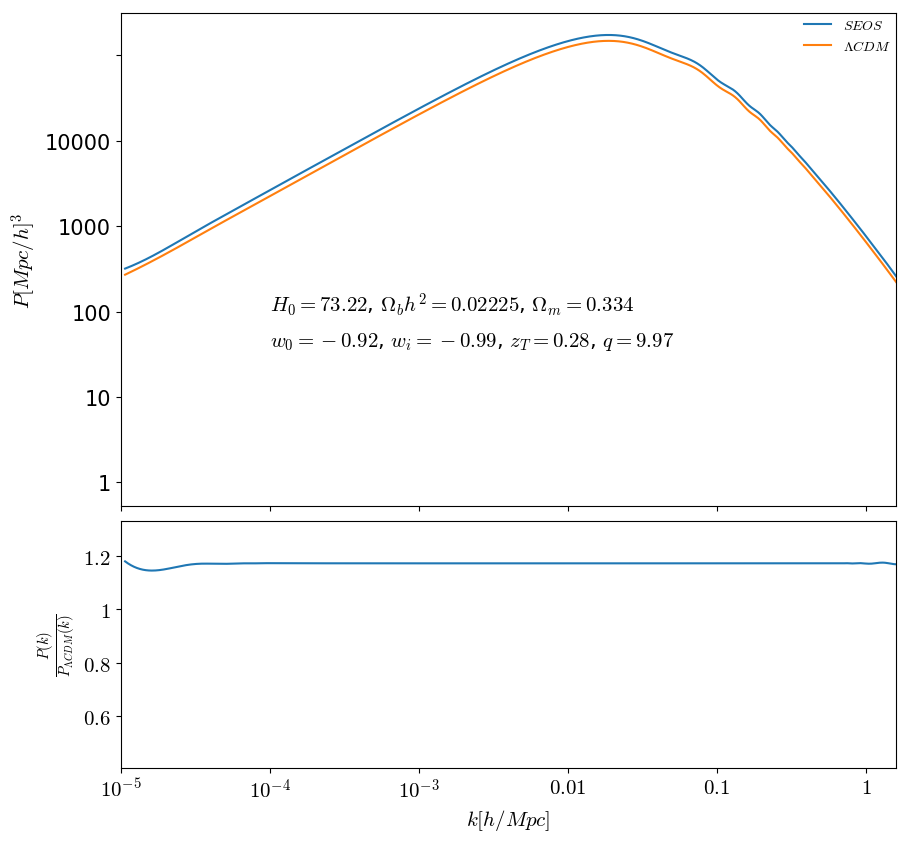

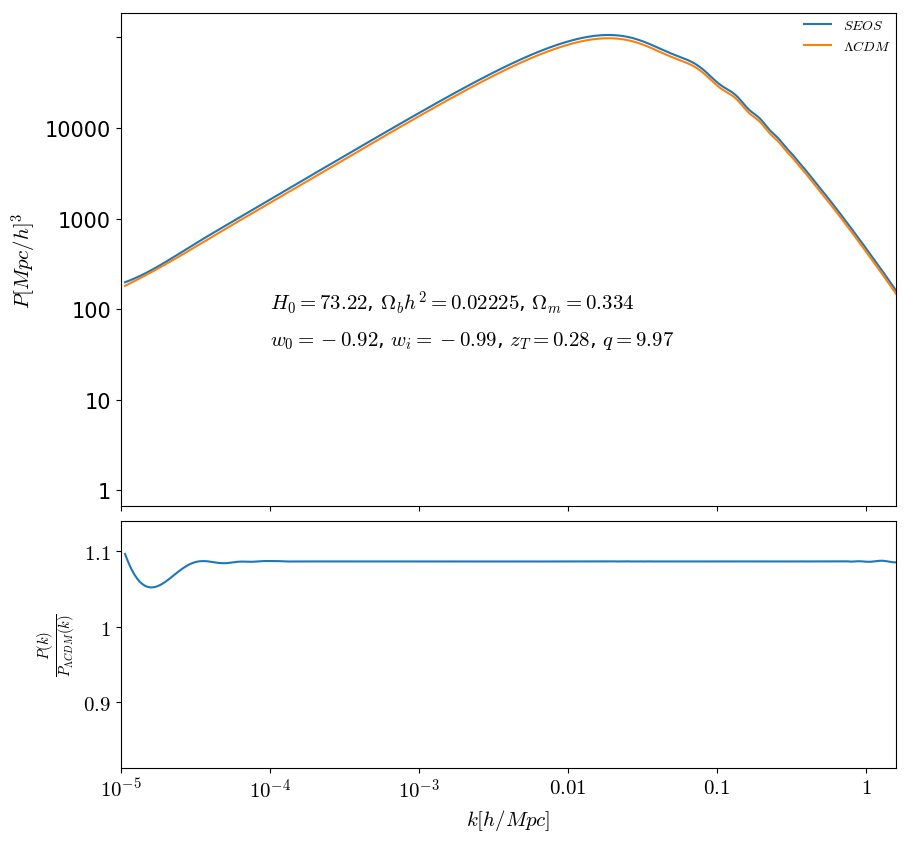

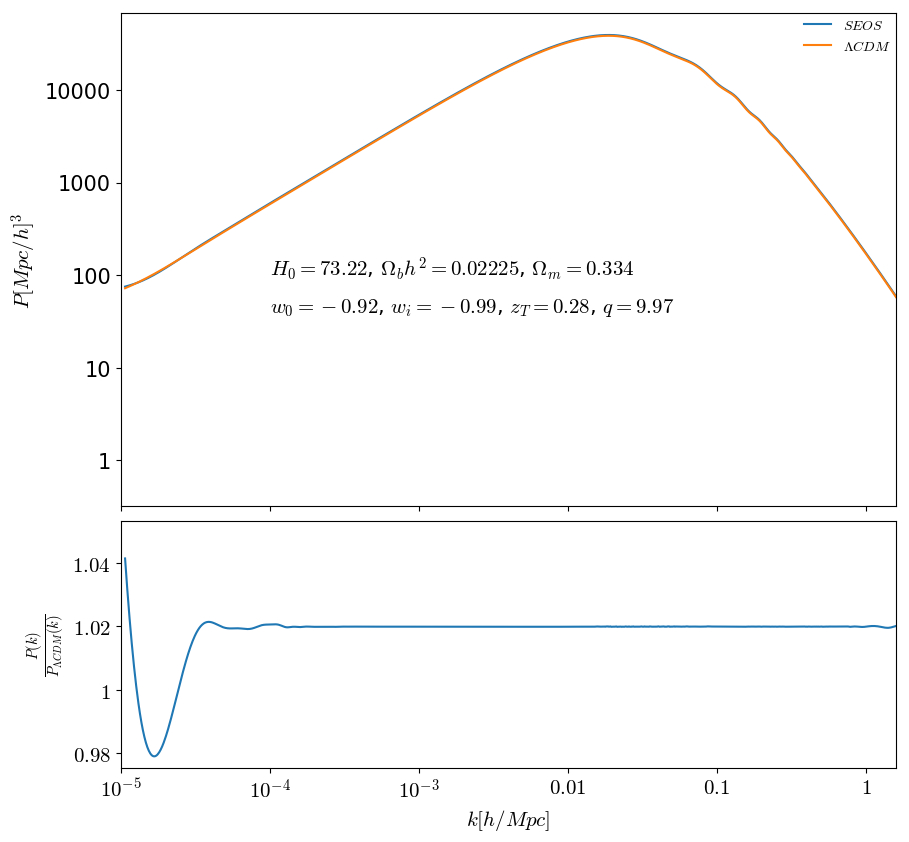

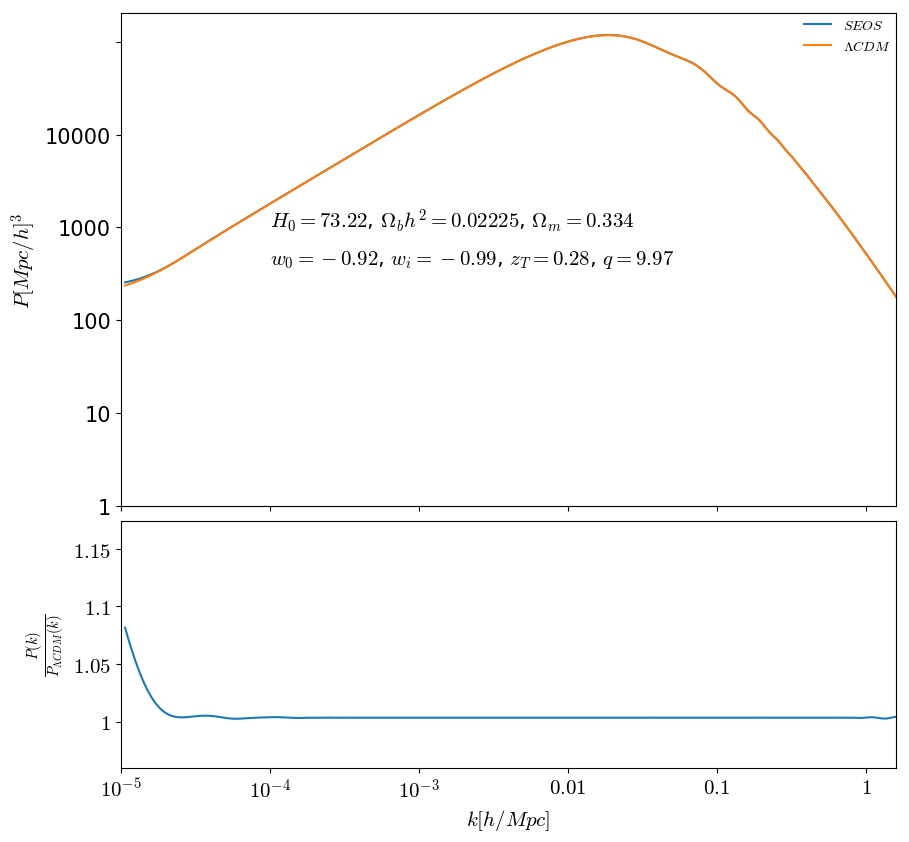

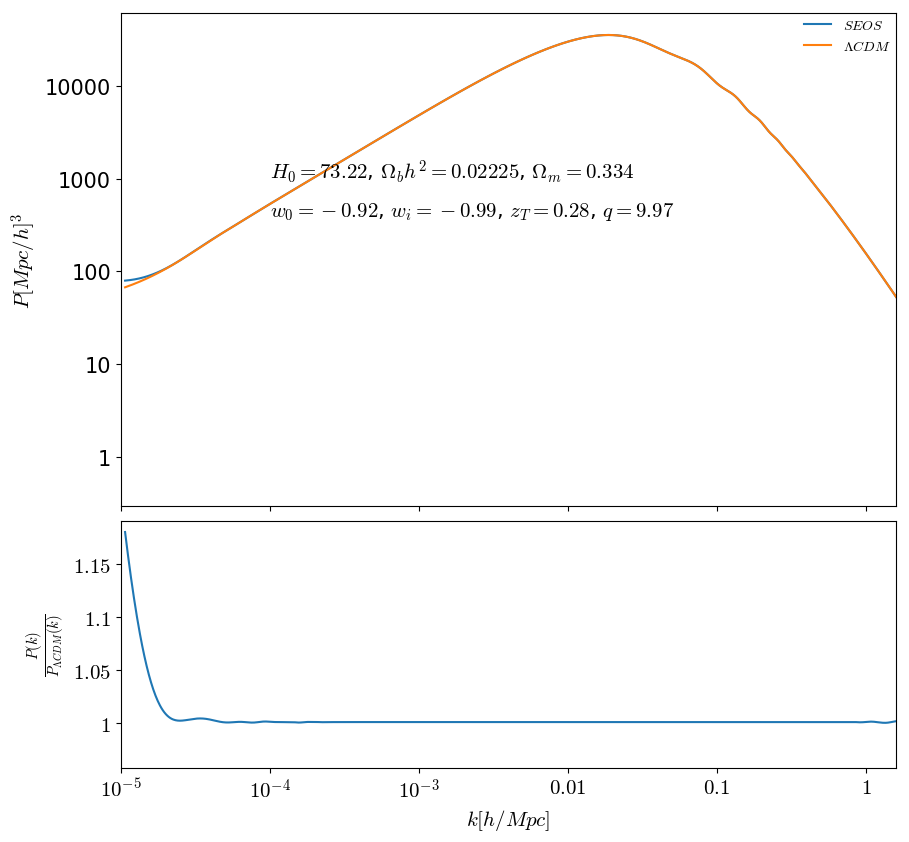

In [134]:
seosroot = 'seosv1z'
lcdmroot = 'lcdmz'
snapshot = [1, 2, 3, 4, 5, 6, 7]#corresponding to z= 0, 0.28, 0.57, 1, 2.3, 5, 10

for s in snapshot:
    pkseos = np.loadtxt(path+seosroot+str(s)+'_pk.dat')
    pklcdm = np.loadtxt(path+lcdmroot+str(s)+'_pk.dat')
    
    pkseos_spl = interp_spline(pkseos)
    pklcdm_spl = interp_spline(pklcdm)
    
    plot_pk(pkseos_spl, pklcdm_spl, s)
    
    

In [ ]:
#first we take both the k's and P(k) for 2 different models at same redshift
seosz0 = pkz0seos[:]
lcdmz0 = pkz0lcmd[:]

#use spline (3rd up to 4th order) to interpolate k's and P(k)
seosz0_rep = splrep(seosz0[:, 0], seosz0[:, 1], k=4)
lcdmz0_rep = splrep(lcdmz0[:, 0], lcdmz0[:, 1], k=4)

#we make a list of k's to map the interpolation into it
#we keep within the minimum/maximum values of both (to avoid extrapolation)
#logspace
krange = logspace(log10(1.07e-5), 1, 1200)

#now we use spline to interpolate the values of P(k) into the array 
pkseosz0_ev = splev(krange, seosz0_rep)
pklcdmz0_ev = splev(krange, lcdmz0_rep)

#plot(krange, pk1_ev)
#plot(krange, pk2_ev)

figure(figsize=(5, 3), dpi=100)

plot(krange, pkseosz0_ev / pklcdmz0_ev)

#xlim(3e-5,10)

xscale('log')
yscale('linear')